# Master INFO - Mini projet
## Évaluation de modèles d'embeddings de topic

**Année 2025/2026**

## Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from embeddingTopicEvaluatorLib.metrics.diversity import diversity
from embeddingTopicEvaluatorLib.metrics.coherence import coherence
from embeddingTopicEvaluatorLib.metrics.retrieval import retrieval
from embeddingTopicEvaluatorLib.config.config import settings

from embeddingTopicEvaluatorLib.models.bertopic_wrapper import TopicModelEvaluatorBERTopic

## Dataset

In [2]:
from datasets import load_dataset
db = load_dataset("ag_news", split="train")
docs = db["text"]

## Config

In [3]:
config = settings.BERTOPIC_CONFIG_HDBSCAN

In [4]:
nr_topics_param = np.linspace(10, 200, 20, dtype=int)

## Train

In [5]:
topic_models = []
for param in nr_topics_param:
    config["BERTopic"]["nr_topics"] = int(param)
    topic_models.append(TopicModelEvaluatorBERTopic(config))

In [6]:
topics_hdbscans = []
probs_hdbscans = []

for model in topic_models:
    topics_hdbscan, probs_hdbscan = model.evaluate(docs)
    
    topics_hdbscans.append(topics_hdbscan)
    probs_hdbscans.append(probs_hdbscan)

2026-03-09 20:45:55,078 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 3750/3750 [03:00<00:00, 20.79it/s]
2026-03-09 20:48:59,572 - BERTopic - Embedding - Completed ✓
2026-03-09 20:48:59,574 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 20:50:19,035 - BERTopic - Dimensionality - Completed ✓
2026-03-09 20:50:19,040 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 20:50:25,541 - BERTopic - Cluster - Completed ✓
2026-03-09 20:50:25,543 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-09 20:50:28,106 - BERTopic - Representation - Completed ✓
2026-03-09 20:50:28,108 - BERTopic - Topic reduction - Reducing number of topics
2026-03-09 20:50:28,240 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 20:50:30,415 - BERTopic - Representation - Completed ✓
2026-03-09 20:50:30,427 - BERTopic - Topic reduction - 

## Evaluation

In [7]:
coherences = []
retrievals = []
diversities = []

for model in topic_models:
    coherence_stack = coherence(model)
    valeurs_sans_outliers = [valeur for cle, valeur in coherence_stack.items() if cle != -1]
    coherence_mean = np.mean(valeurs_sans_outliers)
    coherences.append(coherence_mean)

    retrieval_stack = retrieval(model, docs)
    retrievals.append(retrieval_stack)
    
    diversity_stack = diversity(model)
    diversities.append(diversity_stack)

## Analyse

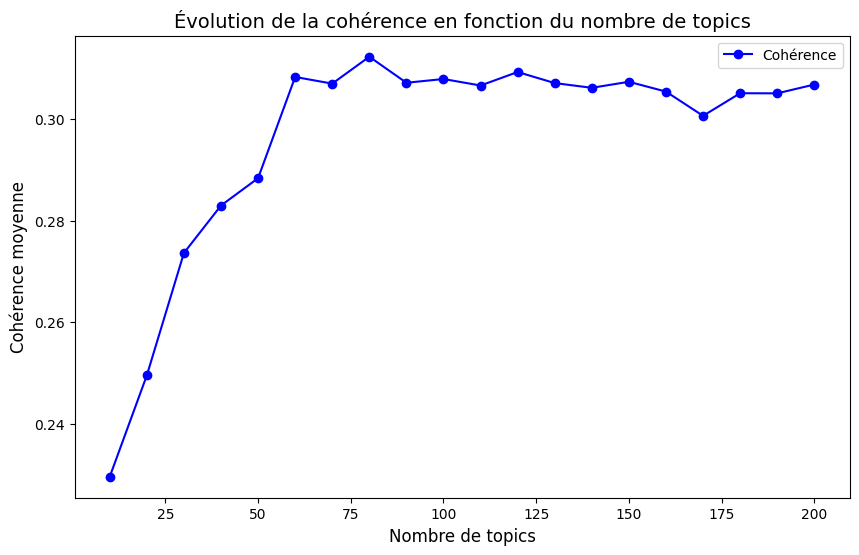

In [10]:
fig = plt.figure(figsize=(10, 6))

plt.plot(nr_topics_param, coherences, marker='o', linestyle='-', color='b', label='Cohérence')

plt.title("Évolution de la cohérence en fonction du nombre de topics", fontsize=14)
plt.xlabel("Nombre de topics", fontsize=12)
plt.ylabel("Cohérence moyenne", fontsize=12)

plt.legend()
plt.show()

In [11]:
fig.savefig('Coherence.png')

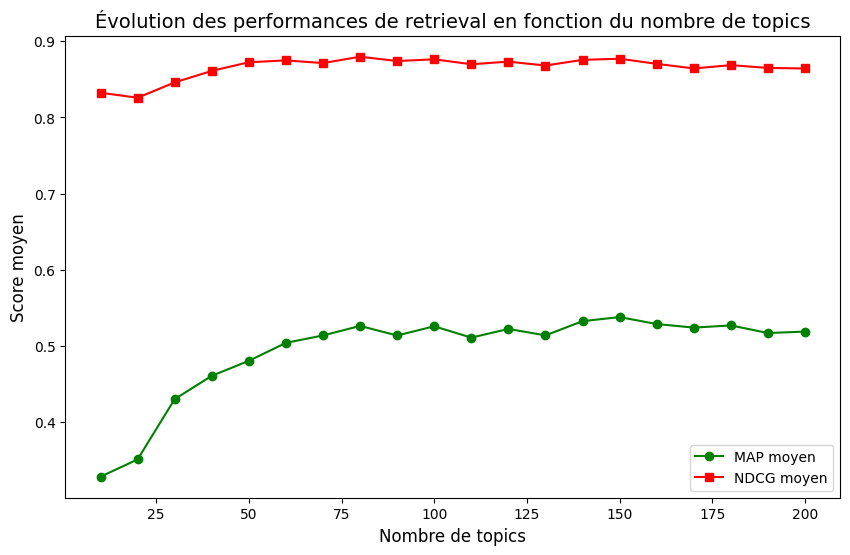

In [12]:
mean_maps = [np.mean([val['map'] for val in res.values()]) for res in retrievals]
mean_ndcgs = [np.mean([val['ndcg'] for val in res.values()]) for res in retrievals]

fig = plt.figure(figsize=(10, 6))

plt.plot(nr_topics_param, mean_maps, marker='o', linestyle='-', color='g', label='MAP moyen')
plt.plot(nr_topics_param, mean_ndcgs, marker='s', linestyle='-', color='r', label='NDCG moyen')

plt.title("Évolution des performances de retrieval en fonction du nombre de topics", fontsize=14)
plt.xlabel("Nombre de topics", fontsize=12)
plt.ylabel("Score moyen", fontsize=12)

plt.legend()
plt.show()

In [13]:
fig.savefig('Retrieval.png')

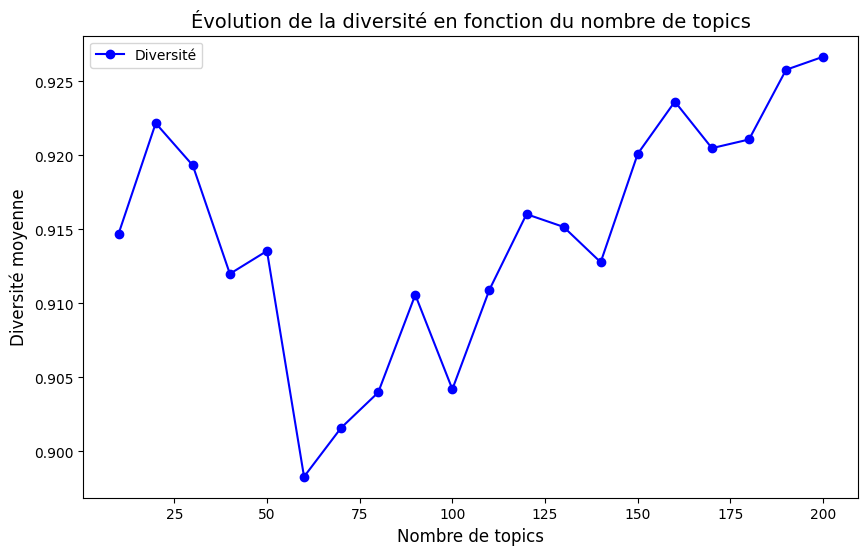

In [14]:
fig = plt.figure(figsize=(10, 6))

plt.plot(nr_topics_param, diversities, marker='o', linestyle='-', color='b', label='Diversité')

plt.title("Évolution de la diversité en fonction du nombre de topics", fontsize=14)
plt.xlabel("Nombre de topics", fontsize=12)
plt.ylabel("Diversité moyenne", fontsize=12)

# plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [15]:
fig.savefig('Diversite.png')